# Task 6: Single-Qubit Readout Simulation

This notebook simulates the classical cavity readout process. It models the interaction between a readout drive, a resonator, and a measurement chain to study the IQ distribution and discrimination of qubit states 0 and 1.

The simulation includes:
- Dispersive shift of the resonator based on the qubit state.
- Noise in the input drive and the amplification chain.
- ADC sampling and heterodyne demodulation to produce IQ signals.
- IQ cloud analysis and discrimination.

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from musiq.workflow import create_model

def pairs_to_complex(values):
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 1:
        return arr.astype(complex)
    return arr[:, 0] + 1j * arr[:, 1]

MODEL_DIR = Path(".")

In [2]:
model = create_model(
    circuits=MODEL_DIR / "circuit.yaml",
    analysers=MODEL_DIR / "analyser.yaml",
    solvers=MODEL_DIR / "solver.yaml",
    devices=MODEL_DIR / "device.yaml",
    pulses=MODEL_DIR / "pulse.yaml",
    # solvers=MODEL_DIR / "solver_cqed.yaml",
    # devices=MODEL_DIR / "device_cqed.yaml",
    # pulses=MODEL_DIR / "pulse_cqed.yaml",
)
solver_id = next(iter(model.solvers))
# model.solvers[solver_id].run.mcwf_ntraj = 1000
model.run_all()


In [3]:
study_0 = 'prep_0'
study_1 = 'prep_1'
tr0 = model.get_trajectory(solver_id, study_name=study_0)
tr1 = model.get_trajectory(solver_id, study_name=study_1)
ana0 = model.analyses['case_0']
ana1 = model.analyses['case_1']
ana2 = model.analyses['summary_0']

print('readout keys prep_0 =', sorted((tr0.classical or {}).get('readout', {}).keys()))
print('analyses: ', sorted(model.analyses.keys()))

readout keys prep_0 = ['a_in', 'a_out', 'cavity_a', 'cavity_n', 'chain', 'equations', 'feedback', 'heterodyne_current', 'line_state', 'measured_voltage', 'shots', 'times']
analyses:  ['case_0', 'case_1', 'summary_0']


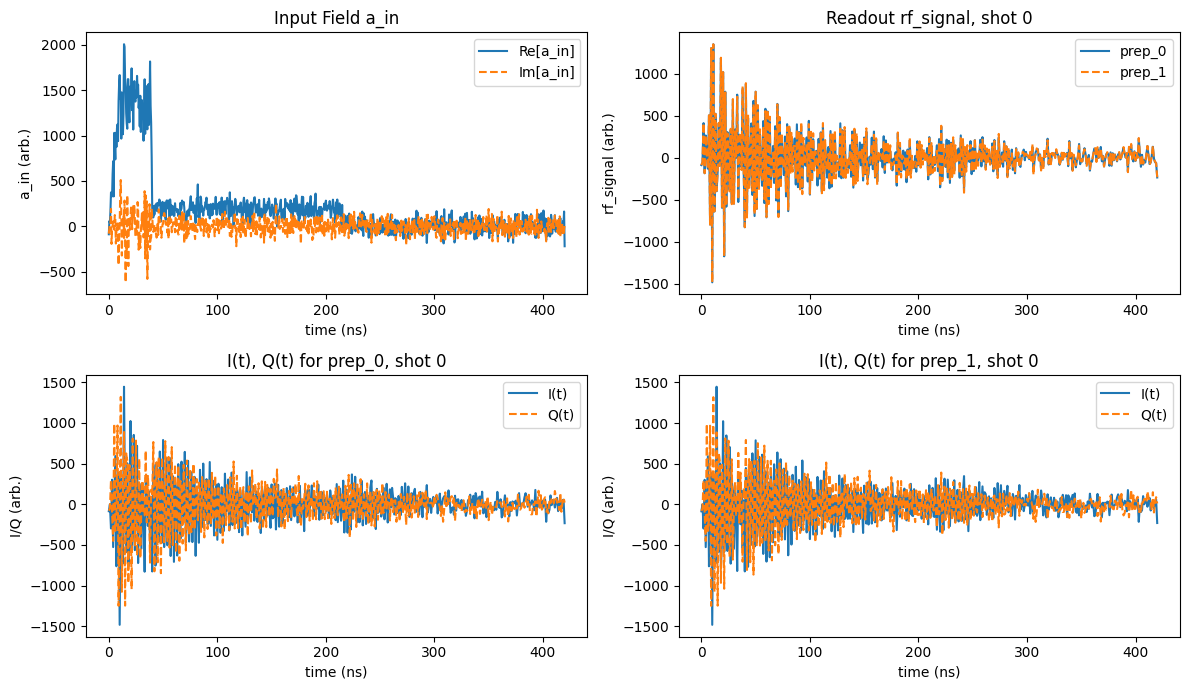

In [4]:
shot_index = 0

t_in_ns_0 = np.asarray(tr0.classical['readout']['times'], dtype=float) * 1e9
t_in_ns_1 = np.asarray(tr1.classical['readout']['times'], dtype=float) * 1e9
a_in0 = pairs_to_complex(tr0.classical['readout']['shots'][shot_index]['a_in'])
a_in1 = pairs_to_complex(tr1.classical['readout']['shots'][shot_index]['a_in'])

t_adc_ns_0 = np.asarray(ana0.output.readout.adc_times) * 1e9
rf_0 = np.asarray(ana0.output.readout.get_rf_signal(shot_index))
rf_1 = np.asarray(ana1.output.readout.get_rf_signal(shot_index))

I_0, Q_0 = zip(*ana0.output.readout.get_if_signal(0))
I_1, Q_1 = zip(*ana1.output.readout.get_if_signal(0))

fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharex=False)
ax[0, 0].plot(t_in_ns_0, a_in0.real, label='Re[a_in]')
ax[0, 0].plot(t_in_ns_0, a_in0.imag, '--', label='Im[a_in]')
ax[0, 0].set_title('Input Field a_in')
ax[0, 0].set_xlabel('time (ns)')
ax[0, 0].set_ylabel('a_in (arb.)')
ax[0, 0].legend()

ax[0, 1].plot(t_adc_ns_0, rf_0[:,0], label=f'prep_0')
ax[0, 1].plot(t_adc_ns_0, rf_1[:,0], '--', label=f'prep_1')
ax[0, 1].set_title(f'Readout rf_signal, shot {shot_index}')
ax[0, 1].set_xlabel('time (ns)')
ax[0, 1].set_ylabel('rf_signal (arb.)')
ax[0, 1].legend()

ax[1, 0].plot(t_adc_ns_0, I_0, label=f'I(t)')
ax[1, 0].plot(t_adc_ns_0, Q_0, '--', label=f'Q(t)')
ax[1, 0].set_title(f'I(t), Q(t) for prep_0, shot {shot_index}')
ax[1, 0].set_xlabel('time (ns)')
ax[1, 0].set_ylabel('I/Q (arb.)')
ax[1, 0].legend()

ax[1, 1].plot(t_adc_ns_0, I_1, label=f'I(t)')
ax[1, 1].plot(t_adc_ns_0, Q_1, '--', label=f'Q(t)')
ax[1, 1].set_title(f'I(t), Q(t) for prep_1, shot {shot_index}')
ax[1, 1].set_xlabel('time (ns)')
ax[1, 1].set_ylabel('I/Q (arb.)')
ax[1, 1].legend()

plt.tight_layout()
plt.show()


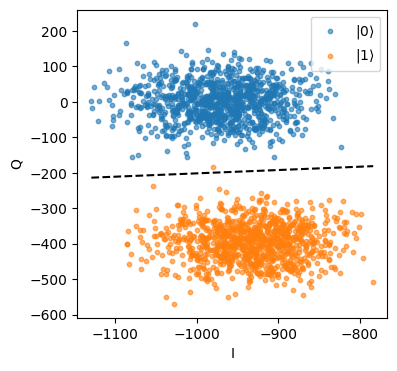

In [5]:
iq_0 = np.asarray(ana2.output.iq_clouds['prep_0'])
iq_1 = np.asarray(ana2.output.iq_clouds['prep_1'])
line_data = ana2.output.discrimination_line
midpoint = np.array(line_data['midpoint'])
normal = np.array(line_data['normal'])

# 2. 创建画布
fig, ax = plt.subplots(figsize=(4, 4))

# 3. 绘制 IQ 云点
ax.scatter(iq_0[:, 0], iq_0[:, 1], label=r'$|0\rangle$', alpha=0.6, s=10)
ax.scatter(iq_1[:, 0], iq_1[:, 1], label=r'$|1\rangle$', alpha=0.6, s=10)

# 4. 绘制分割线
# 计算x的范围（基于所有数据的边界，确保线段覆盖图表）
all_iq = np.vstack([iq_0, iq_1])
x_min, x_max = all_iq[:, 0].min(), all_iq[:, 0].max()
x_vals = np.array([x_min, x_max])

# 根据法线方程 y = -(nx/ny)*(x - x0) + y0 计算 y
# 注意：如果 normal[1] 为 0，则线是垂直的，需要单独处理
if normal[1] != 0:
    y_vals = -(normal[0] / normal[1]) * (x_vals - midpoint[0]) + midpoint[1]
    ax.plot(x_vals, y_vals, color='black', linestyle='--')
else:
    # 垂直线情况
    ax.axvline(x=midpoint[0], color='black', linestyle='--')

# 5. 图表修饰
ax.set_xlabel('I')
ax.set_ylabel('Q')
ax.legend()
# ax.set_aspect('equal') # 建议设置为 equal，否则 IQ 比例失真
plt.show() # 使用 plt.show() 代替直接写 fig，避免重复显示

In [6]:
import sys
import os
sys.path.append(os.path.abspath('../../dev'))

from dump_structure import dump_structure

with open("model_structure.txt", "w", encoding="utf-8") as f:
    dump_structure(model, max_depth=8, file=f)
